In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [3]:
def train_and_evaluate(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)

    y_train_prob = model.predict_proba(X_train)
    y_val_prob = model.predict_proba(X_val)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_loss = log_loss(y_train, y_train_prob)
    val_loss = log_loss(y_val, y_val_prob)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    weights = model.coef_.flatten()

    return train_loss, val_loss, train_acc, val_acc, weights

In [7]:
baseline_model = LogisticRegression(
    penalty=None, solver="saga", max_iter=10000
)

baseline_results = train_and_evaluate(
    baseline_model, X_train, y_train, X_val, y_val
)

In [6]:
l1_model = LogisticRegression(
    penalty="l1", solver="saga", C=1.0, max_iter=5000
)

l1_results = train_and_evaluate(
    l1_model, X_train, y_train, X_val, y_val
)

l1_zero_weights = np.sum(l1_results[4] == 0)


In [8]:
l2_model = LogisticRegression(
    penalty="l2", solver="saga", C=1.0, max_iter=5000
)

l2_results = train_and_evaluate(
    l2_model, X_train, y_train, X_val, y_val
)

In [9]:
elastic_model = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    C=1.0,
    l1_ratio=0.5,
    max_iter=5000
)

elastic_results = train_and_evaluate(
    elastic_model, X_train, y_train, X_val, y_val
)

In [10]:
results_df = pd.DataFrame({
    "Model": ["Baseline", "L1", "L2", "Elastic Net"],
    "Train Loss": [
        baseline_results[0],
        l1_results[0],
        l2_results[0],
        elastic_results[0]
    ],
    "Validation Loss": [
        baseline_results[1],
        l1_results[1],
        l2_results[1],
        elastic_results[1]
    ],
    "Train Accuracy": [
        baseline_results[2],
        l1_results[2],
        l2_results[2],
        elastic_results[2]
    ],
    "Validation Accuracy": [
        baseline_results[3],
        l1_results[3],
        l2_results[3],
        elastic_results[3]
    ]
})

results_df

,Model,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,Baseline,0.024405,0.148386,0.991209,0.956140
1,L1,0.053682,0.068824,0.986813,0.964912
2,L2,0.054493,0.059933,0.986813,0.973684
3,Elastic Net,0.054942,0.062387,0.986813,0.973684


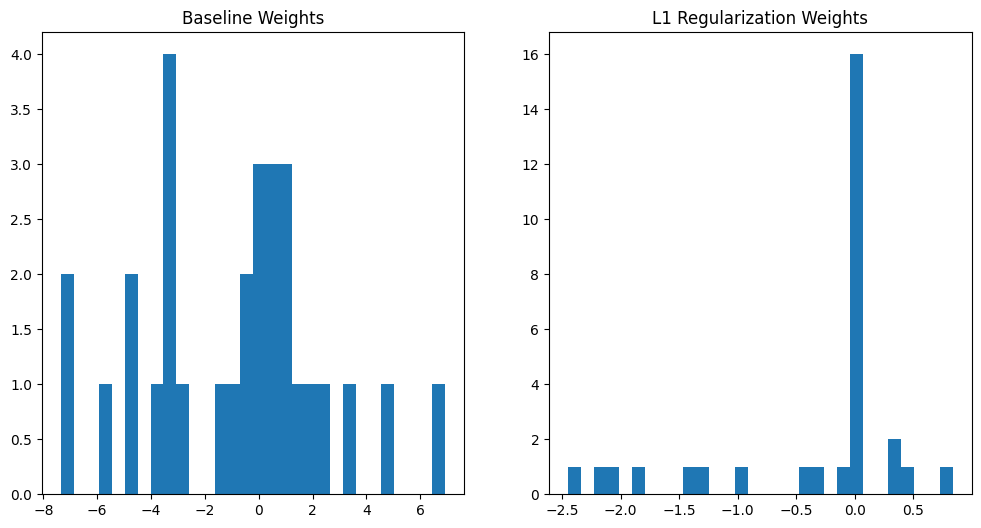

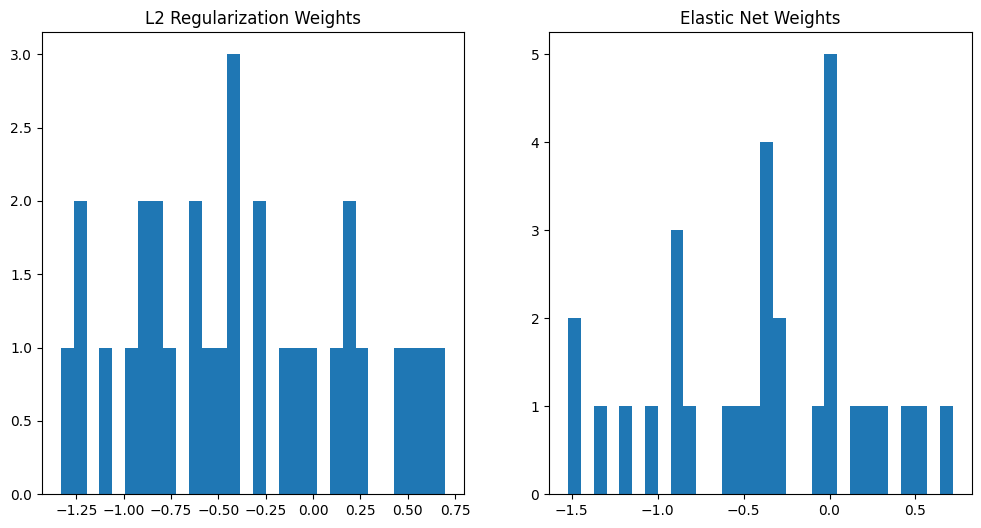

In [11]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(baseline_results[4], bins=30)
plt.title("Baseline Weights")

plt.subplot(1,2,2)
plt.hist(l1_results[4], bins=30)
plt.title("L1 Regularization Weights")

plt.show()

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(l2_results[4], bins=30)
plt.title("L2 Regularization Weights")

plt.subplot(1,2,2)
plt.hist(elastic_results[4], bins=30)
plt.title("Elastic Net Weights")

plt.show()
